In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [18]:
df = pd.read_csv('city_day.csv')
df

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [19]:
df_kolkata=df.iloc[19042:19846].copy()
df_kolkata.tail(3)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
19843,Kolkata,2020-06-29,14.53,32.40,5.42,15.98,21.45,7.59,0.45,7.01,30.64,3.18,9.78,0.34,48.0,Good
19844,Kolkata,2020-06-30,14.00,35.85,6.25,12.29,18.12,9.64,0.37,5.66,24.59,2.46,10.75,0.27,47.0,Good
19845,Kolkata,2020-07-01,10.53,31.58,6.25,10.01,16.29,12.87,0.30,4.32,15.52,1.82,10.25,0.18,45.0,Good


In [20]:
df_kolkata.isnull().sum()

City            0
Date            0
PM2.5          53
PM10           53
NO             25
NO2            25
NOx             0
NH3             0
CO              0
SO2            54
O3             49
Benzene         0
Toluene         0
Xylene        410
AQI            57
AQI_Bucket     57
dtype: int64

In [21]:
df_kolkata.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [22]:
df_kolkata = df.iloc[19042:19846].copy()
df_kolkata = df_kolkata[['City', 'Date', 'PM2.5', 'PM10','NO2','CO', 'SO2','AQI','AQI_Bucket']]
df_kolkata = df_kolkata.rename(columns={'PM2.5':'PM-2.5', 'PM10':'PM-10', 'AQI_Bucket': 'AQI_Status'})
df_kolkata

,City,Date,PM-2.5,PM-10,NO2,CO,SO2,AQI,AQI_Status
19042,Kolkata,2018-04-20,NaN,NaN,25.24,1.16,NaN,NaN,NaN
19043,Kolkata,2018-04-21,NaN,NaN,26.30,1.13,NaN,NaN,NaN
19044,Kolkata,2018-04-22,NaN,NaN,29.27,1.09,NaN,NaN,NaN
19045,Kolkata,2018-04-23,NaN,NaN,34.20,1.11,NaN,NaN,NaN
19046,Kolkata,2018-04-24,NaN,NaN,52.42,1.01,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
19841,Kolkata,2020-06-27,7.89,24.73,9.25,0.35,5.73,37.0,Good
19842,Kolkata,2020-06-28,10.58,25.56,12.63,0.38,5.92,43.0,Good
19843,Kolkata,2020-06-29,14.53,32.40,15.98,0.45,7.01,48.0,Good
19844,Kolkata,2020-06-30,14.00,35.85,12.29,0.37,5.66,47.0,Good


In [23]:
df_kolkata = df_kolkata.dropna(subset=['AQI'])
df_kolkata

,City,Date,PM-2.5,PM-10,NO2,CO,SO2,AQI,AQI_Status
19099,Kolkata,2018-06-16,47.55,128.66,24.89,0.72,7.30,119.0,Moderate
19100,Kolkata,2018-06-17,45.04,107.03,40.85,1.63,1.34,113.0,Moderate
19101,Kolkata,2018-06-18,50.10,105.68,33.28,1.47,3.02,107.0,Moderate
19102,Kolkata,2018-06-19,39.25,87.24,30.86,1.35,1.93,148.0,Moderate
19103,Kolkata,2018-06-20,24.44,53.19,38.03,1.70,6.88,94.0,Satisfactory
...,...,...,...,...,...,...,...,...,...
19841,Kolkata,2020-06-27,7.89,24.73,9.25,0.35,5.73,37.0,Good
19842,Kolkata,2020-06-28,10.58,25.56,12.63,0.38,5.92,43.0,Good
19843,Kolkata,2020-06-29,14.53,32.40,15.98,0.45,7.01,48.0,Good
19844,Kolkata,2020-06-30,14.00,35.85,12.29,0.37,5.66,47.0,Good


In [24]:
df_kolkata.isnull().sum()

City          0
Date          0
PM-2.5        0
PM-10         0
NO2           0
CO            0
SO2           0
AQI           0
AQI_Status    0
dtype: int64

In [25]:
df_kolkata['Date'] = pd.to_datetime(df_kolkata['Date'])
df_kolkata_pivot = df_kolkata.pivot_table(index=df_kolkata['Date'].dt.year, columns=df_kolkata['Date'].dt.month, values='AQI', aggfunc='mean')
df_kolkata_pivot

Date,1,2,3,4,5,6,7,8,9,10,11,12
Date,,,,,,,,,,,,
2018,NaN,NaN,NaN,NaN,NaN,75.333333,51.612903,70.322581,83.066667,163.064516,283.666667,338.258065
2019,360.838710,266.071429,157.774194,86.800000,88.548387,71.633333,61.935484,54.064516,46.366667,125.516129,204.933333,208.903226
2020,216.935484,197.724138,122.838710,70.366667,53.161290,46.466667,45.000000,NaN,NaN,NaN,NaN,NaN


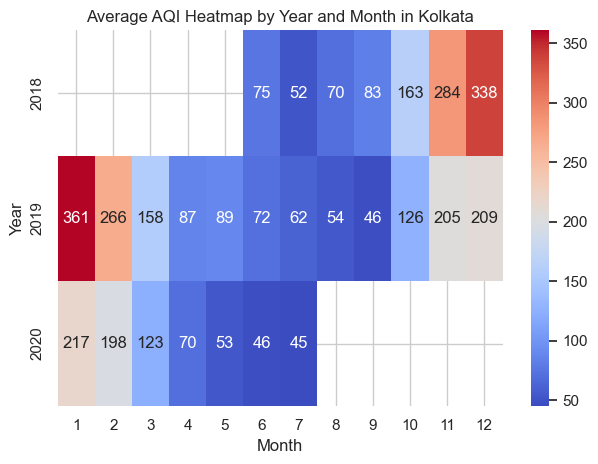

In [26]:
sns.set_theme(style = "whitegrid")

# plot for passengers in each month of every year (a 2d array)
sns.heatmap(
    df_kolkata_pivot,
    cmap = "coolwarm",
    annot = True,  # for showing the values in each grid
    fmt = ".0f"  # shows format of data as floats with 0 decimal places
)

plt.title("Average AQI Heatmap by Year and Month in Kolkata")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

In [27]:
df_kolkata['Date_ordinal'] = df_kolkata['Date'].apply(lambda x: x.toordinal())

features = ['PM-2.5', 'PM-10', 'NO2', 'CO', 'SO2', 'Date_ordinal']
X = df_kolkata[features]
y = df_kolkata['AQI']

print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Features (X) head:
       PM-2.5   PM-10    NO2    CO   SO2  Date_ordinal
19099   47.55  128.66  24.89  0.72  7.30        736861
19100   45.04  107.03  40.85  1.63  1.34        736862
19101   50.10  105.68  33.28  1.47  3.02        736863
19102   39.25   87.24  30.86  1.35  1.93        736864
19103   24.44   53.19  38.03  1.70  6.88        736865

Target (y) head:
19099    119.0
19100    113.0
19101    107.0
19102    148.0
19103     94.0
Name: AQI, dtype: float64


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared: {r2:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")

R-squared: 0.953
Mean Absolute Error (MAE): 15.993
Mean Squared Error (MSE): 530.379


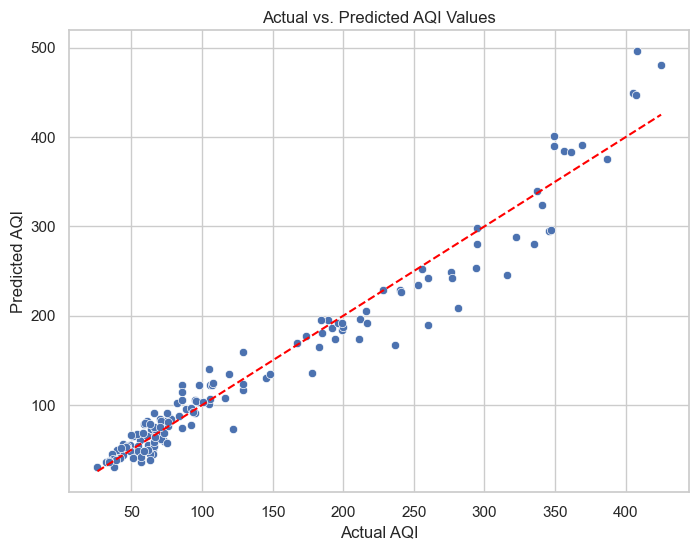

In [30]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Actual vs. Predicted AQI Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.grid(True)
plt.show()

In [31]:
import datetime

input_pm25 = 90.0
input_pm10 = 60.0
input_no2 = 60.0
input_co = 3.0
input_so2 = 8
input_date_str = '2023-01-15'

input_date_ordinal = pd.to_datetime(input_date_str).toordinal()

new_data = pd.DataFrame([[input_pm25, input_pm10, input_no2, input_co, input_so2, input_date_ordinal]],
                          columns=features)

predicted_aqi = model.predict(new_data)

print(f"Input Pollutant Values:")
print(f"  PM2.5: {input_pm25}")
print(f"  PM10: {input_pm10}")
print(f"  NO2: {input_no2}")
print(f"  CO: {input_co}")
print(f"  SO2: {input_so2}")
print(f"  Date: {input_date_str}")
print(f"\nPredicted AQI: {predicted_aqi[0]:.2f}")

Input Pollutant Values:
  PM2.5: 90.0
  PM10: 60.0
  NO2: 60.0
  CO: 3.0
  SO2: 8
  Date: 2023-01-15

Predicted AQI: 166.39
